<a href="https://colab.research.google.com/github/ozt07/Aranda/blob/main/Grupo10_Notebook2_Librerias_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Implementación Profesional con LightGBM
## Inteligencia Artificial I — Actividad 2 | Grupo 10
**Integrantes:** Carrillo Orozco Bairon Enrique | Rodríguez Martínez Paula Tatiana | Tovar Prieto Oscar Fernando

---

## 1. Introducción y Descripción del Problema

### ¿Qué problema vamos a resolver?
**Predicción de Churn de Clientes de Telecomunicaciones**

El *churn* (abandono) de clientes es uno de los problemas más costosos para empresas de telecomunicaciones. Perder un cliente puede costar entre 5 y 25 veces más que retenerlo. Predecir qué clientes tienen alta probabilidad de cancelar su servicio permite a las empresas actuar de forma preventiva con ofertas personalizadas.

### ¿Por qué LightGBM para este problema?
- El dataset tiene variables categóricas y numéricas mixtas → LightGBM las maneja nativamente
- El dataset tiene desbalance de clases (~26% churn) → LightGBM tiene parámetro `scale_pos_weight`
- Necesitamos alta precisión con predicciones rápidas → LightGBM es notoriamente eficiente

### Dataset: Telco Customer Churn
- **Fuente**: Simulación basada en el dataset Telco de IBM (disponible en Kaggle)
- **Registros**: 7,043 clientes
- **Features**: 20 variables (demográficas, de servicio, contractuales y financieras)
- **Target**: `Churn` — si el cliente abandonó el servicio (Yes/No)

## 2. Carga y Exploración de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = ['#2ecc71', '#e74c3c']  # Verde=No churn, Rojo=Churn

print("Librerías cargadas ✓")
print(f"LightGBM versión: {lgb.__version__}")

Librerías cargadas ✓
LightGBM versión: 4.6.0


In [2]:
# Cargar dataset
df = pd.read_csv('churn.csv')

print(f"{'='*50}")
print(f"  INFORMACIÓN DEL DATASET")
print(f"{'='*50}")
print(f"  Filas:    {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]}")
print()
df.info()

  INFORMACIÓN DEL DATASET
  Filas:    7,043
  Columnas: 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-nu

In [3]:
# Estadísticas descriptivas de variables numéricas
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7032.00
mean,0.15,35.36,68.83,4261.62
std,0.36,20.63,29.05,2435.07
min,0.00,0.00,18.03,19.94
25%,0.00,18.00,43.84,2138.64
50%,0.00,35.00,69.14,4300.27
75%,0.00,53.00,93.60,6337.12
max,1.00,71.00,118.99,8499.30


In [4]:
# Primeras filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,ID-00000,Male,0,Yes,No,42,Yes,No,No,No,...,No internet service,No,No,No internet service,Month-to-month,Yes,Credit card (automatic),54.21,3912.02,No
1,ID-00001,Female,1,Yes,Yes,68,Yes,No phone service,Fiber optic,No,...,No,No internet service,No internet service,No,Month-to-month,Yes,Electronic check,101.88,4865.30,No
2,ID-00002,Male,0,No,Yes,62,Yes,Yes,Fiber optic,No internet service,...,No internet service,Yes,No,Yes,One year,Yes,Bank transfer (automatic),118.36,6037.68,No
3,ID-00003,Male,0,Yes,No,69,Yes,Yes,DSL,Yes,...,No,No internet service,No internet service,No,Month-to-month,Yes,Credit card (automatic),69.65,4325.25,Yes
4,ID-00004,Male,0,Yes,No,64,Yes,No,Fiber optic,Yes,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Electronic check,67.84,838.18,No


## 3. Análisis Exploratorio de Datos (EDA)

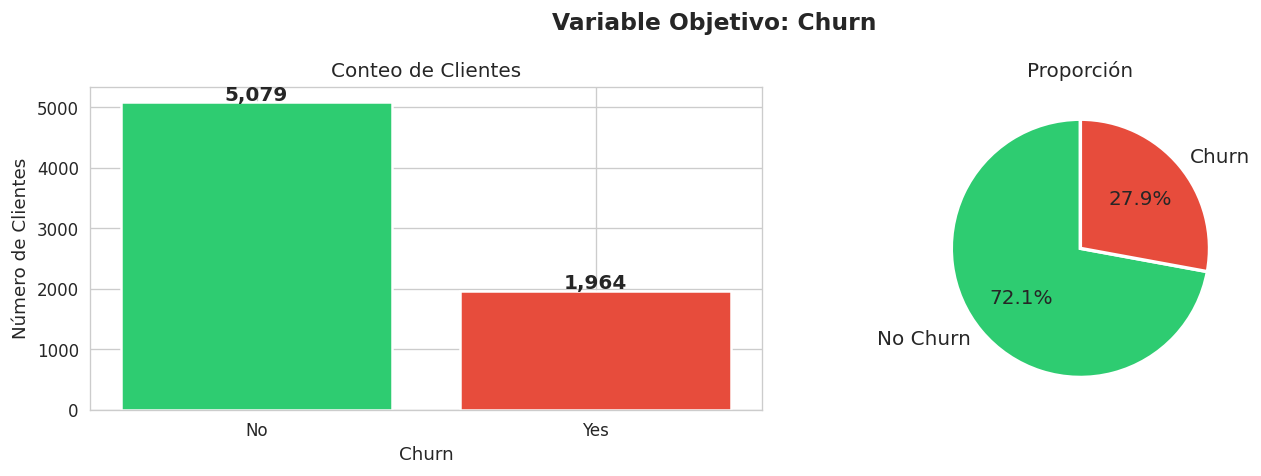

  No Churn: 5,079 (72.1%)
  Churn:    1,964 (27.9%)
  ⚠️  Dataset desbalanceado — se considerará en el modelo


In [5]:
# ─── Distribución de la variable objetivo ───
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Variable Objetivo: Churn', fontsize=14, fontweight='bold')

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

# Conteo
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=PALETTE, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Conteo de Clientes', fontsize=12)
axes[0].set_ylabel('Número de Clientes', fontsize=11)
axes[0].set_xlabel('Churn', fontsize=11)

# Porcentaje (pie)
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción', fontsize=12)

plt.tight_layout()
plt.show()

print(f"  No Churn: {churn_counts['No']:,} ({churn_pct['No']:.1f}%)")
print(f"  Churn:    {churn_counts['Yes']:,} ({churn_pct['Yes']:.1f}%)")
print(f"  ⚠️  Dataset desbalanceado — se considerará en el modelo")

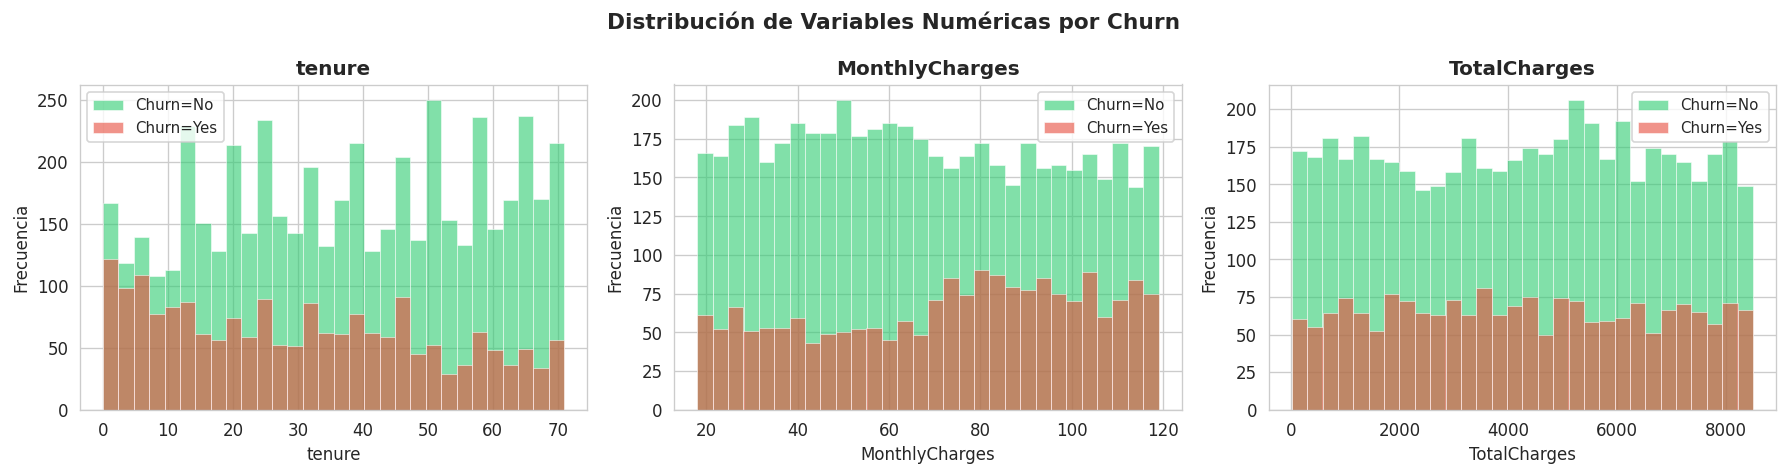

In [6]:
# ─── Variables numéricas vs Churn ───
num_vars = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de Variables Numéricas por Churn', fontsize=13, fontweight='bold')

for ax, var in zip(axes, num_vars):
    for churn_val, color in zip(['No', 'Yes'], PALETTE):
        subset = df[df['Churn'] == churn_val][var].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={churn_val}',
                edgecolor='white', linewidth=0.5)
    ax.set_title(var, fontsize=12, fontweight='bold')
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

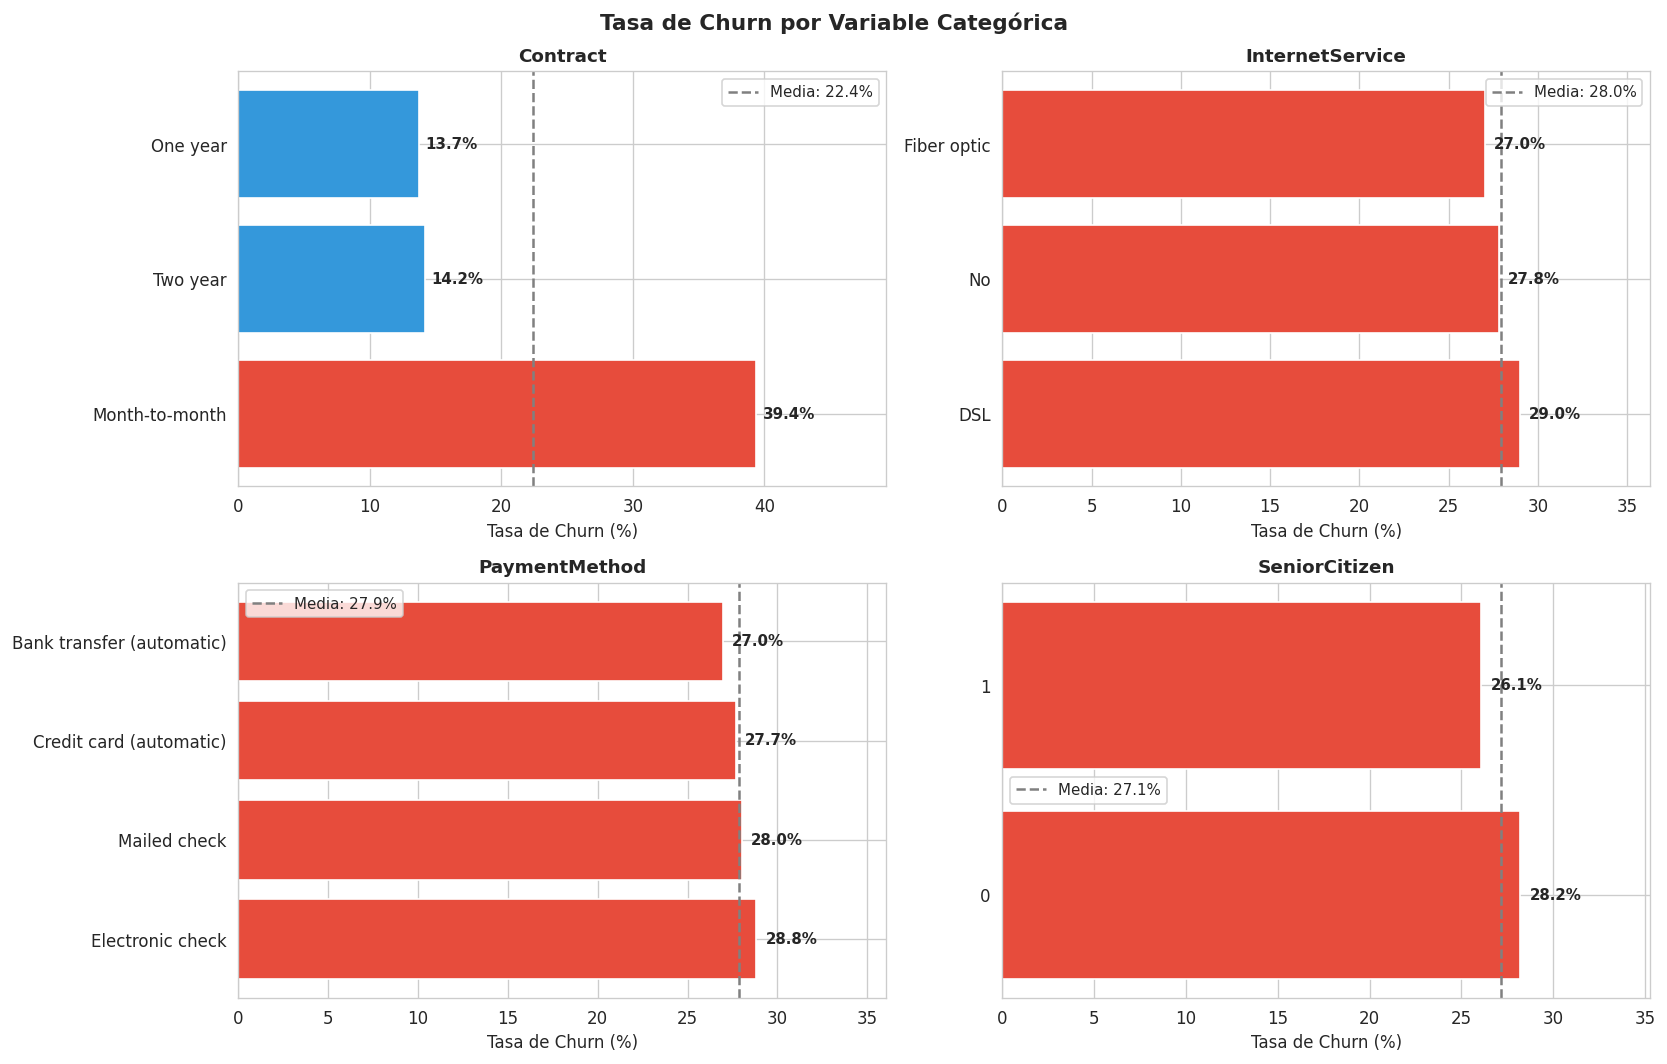

In [7]:
# ─── Variables categóricas clave vs Churn ───
cat_vars = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
fig.suptitle('Tasa de Churn por Variable Categórica', fontsize=13, fontweight='bold')

for ax, var in zip(axes, cat_vars):
    churn_rate = df.groupby(var)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)

    bars = ax.barh(churn_rate.index.astype(str), churn_rate.values,
                   color=['#e74c3c' if v > 25 else '#3498db' for v in churn_rate.values])
    ax.axvline(churn_rate.mean(), color='gray', linestyle='--', linewidth=1.5,
               label=f'Media: {churn_rate.mean():.1f}%')

    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

    ax.set_title(f'{var}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tasa de Churn (%)', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(0, churn_rate.max() * 1.25)

plt.tight_layout()
plt.show()

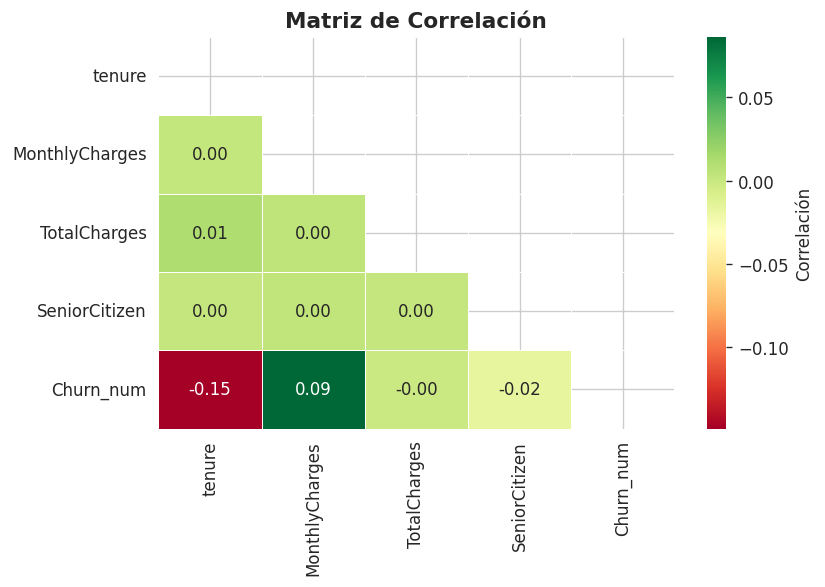

Correlaciones con Churn:
MonthlyCharges    0.086400
TotalCharges     -0.001296
SeniorCitizen    -0.017081
tenure           -0.149290
Name: Churn_num, dtype: float64


In [8]:
# ─── Matriz de correlación (variables numéricas) ───
df_temp = df.copy()
df_temp['Churn_num'] = (df_temp['Churn'] == 'Yes').astype(int)

corr_vars = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']
corr_matrix = df_temp[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Correlación'})
ax.set_title('Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlaciones con Churn:")
print(corr_matrix['Churn_num'].drop('Churn_num').sort_values(ascending=False))

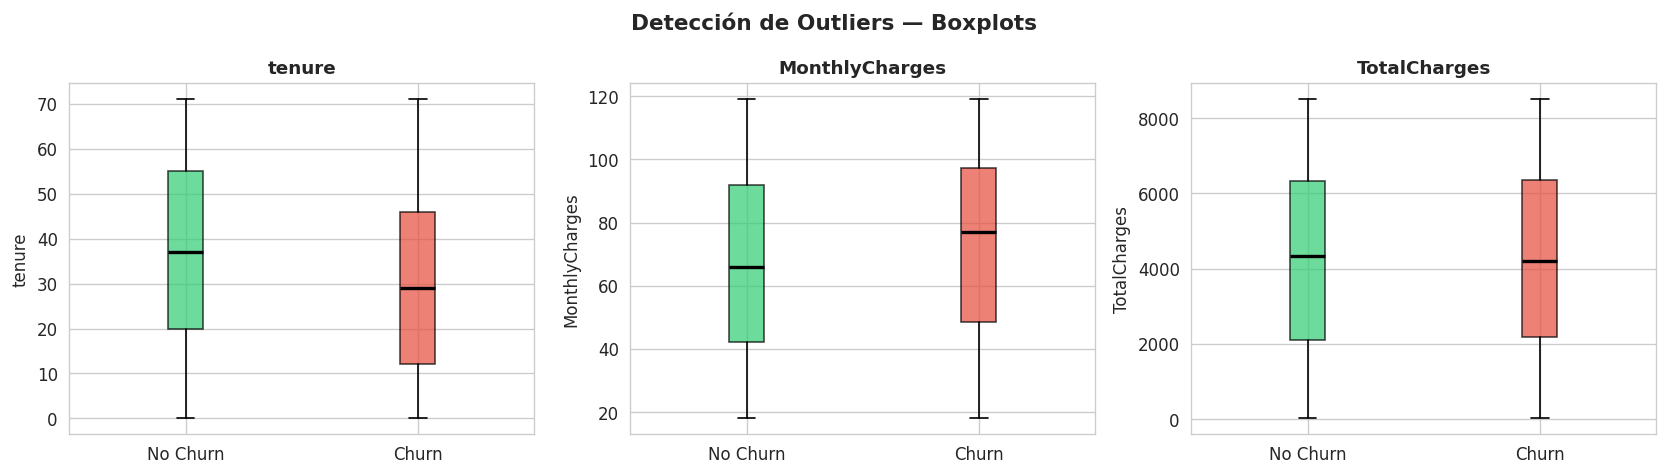

In [ ]:
# ─── Detección de outliers (boxplots) ───
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Detección de Outliers — Boxplots', fontsize=13, fontweight='bold')

for ax, var in zip(axes, num_vars):
    data_no = df[df['Churn'] == 'No'][var].dropna()
    data_yes = df[df['Churn'] == 'Yes'][var].dropna()
    bp = ax.boxplot([data_no, data_yes], labels=['No Churn', 'Churn'],
                    patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_ylabel(var, fontsize=10)

plt.tight_layout()
plt.show()

## 4. Preprocesamiento

In [ ]:
# ─── 4.1 Manejo de valores nulos ───
print("Valores nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

# TotalCharges tiene algunos nulos → imputar con la mediana
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(f"\n✅ Nulos imputados con mediana en TotalCharges")
print(f"   Nulos restantes: {df.isnull().sum().sum()}")

Valores nulos por columna:
TotalCharges    11
dtype: int64

✅ Nulos imputados con mediana en TotalCharges
   Nulos restantes: 0


In [ ]:
# ─── 4.2 Preparar features y target ───
# Eliminar columna ID (no aporta información predictiva)
df_model = df.drop(columns=['customerID'])

# Codificar target
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Separar features y target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f"Features: {X.shape[1]} variables")
print(f"Muestras: {X.shape[0]:,}")
print(f"\nDistribución target: {y.value_counts().to_dict()}")

Features: 19 variables
Muestras: 7,043

Distribución target: {0: 5079, 1: 1964}


In [ ]:
# ─── 4.3 Codificación de variables categóricas ───
cat_columns = X.select_dtypes(include='object').columns.tolist()
num_columns = X.select_dtypes(exclude='object').columns.tolist()

print(f"Variables categóricas ({len(cat_columns)}): {cat_columns}")
print(f"Variables numéricas  ({len(num_columns)}): {num_columns}")

# Label Encoding para variables categóricas
# LightGBM puede usar categorías directamente, pero Label Encoding es más explícito
le = LabelEncoder()
X_encoded = X.copy()
for col in cat_columns:
    X_encoded[col] = le.fit_transform(X[col])

print(f"\n✅ Codificación completada")
X_encoded.head(3)

Variables categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Variables numéricas  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

✅ Codificación completada


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,1,0,42,1,0,2,0,2,1,0,0,1,0,1,1,54.21,3912.02
1,0,1,1,1,68,1,1,1,0,2,0,1,1,0,0,1,2,101.88,4865.30
2,1,0,0,1,62,1,2,1,1,0,1,2,0,2,1,1,0,118.36,6037.68


In [ ]:
# ─── 4.4 División Train/Test ───
# Stratified split para mantener la proporción de churn
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # importante con datos desbalanceados
)

print(f"División Train/Test (80/20 estratificado):")
print(f"  Train: {X_train.shape[0]:,} muestras ({y_train.mean()*100:.1f}% churn)")
print(f"  Test:  {X_test.shape[0]:,} muestras  ({y_test.mean()*100:.1f}% churn)")
print(f"\n✅ La proporción de churn se mantiene en ambos conjuntos")

División Train/Test (80/20 estratificado):
  Train: 5,634 muestras (27.9% churn)
  Test:  1,409 muestras  (27.9% churn)

✅ La proporción de churn se mantiene en ambos conjuntos


In [ ]:
# ─── 4.5 Nota sobre normalización ───
# LightGBM es un algoritmo basado en árboles → NO requiere normalización
# Los árboles son invariantes a escala de features
print("ℹ️  LightGBM es basado en árboles de decisión.")
print("   Los árboles son invariantes a la escala de las variables.")
print("   Por esto, NO se requiere normalización/estandarización.")

ℹ️  LightGBM es basado en árboles de decisión.
   Los árboles son invariantes a la escala de las variables.
   Por esto, NO se requiere normalización/estandarización.


## 5. Entrenamiento del Modelo

In [ ]:
# ─── Calcular peso para clase minoritaria (manejo de desbalance) ───
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight = {n_neg}/{n_pos} = {scale_pos_weight:.2f}")
print(f"(Pesa {scale_pos_weight:.1f}x más los casos de churn)")

scale_pos_weight = 4063/1571 = 2.59
(Pesa 2.6x más los casos de churn)


In [ ]:
# ─── Entrenamiento base con LightGBM ───
lgbm_base = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    scale_pos_weight=scale_pos_weight,  # manejo de desbalance
    random_state=42,
    verbose=-1
)

lgbm_base.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.log_evaluation(period=50)]
)

print("\n✅ Modelo LightGBM entrenado")

[50]	valid_0's binary_logloss: 0.59494


[100]	valid_0's binary_logloss: 0.607521


[150]	valid_0's binary_logloss: 0.608359


[200]	valid_0's binary_logloss: 0.611673


[250]	valid_0's binary_logloss: 0.612274


[300]	valid_0's binary_logloss: 0.613592

✅ Modelo LightGBM entrenado


## 6. Evaluación del Modelo

In [ ]:
# ─── Predicciones y métricas ───
y_pred = lgbm_base.predict(X_test)
y_proba = lgbm_base.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\n{'='*50}")
print(f"  MÉTRICAS DE EVALUACIÓN — LightGBM Base")
print(f"{'='*50}")
print(f"  Accuracy:  {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision: {prec:.4f}  ({prec*100:.1f}%)")
print(f"  Recall:    {rec:.4f}  ({rec*100:.1f}%)")
print(f"  F1-Score:  {f1:.4f}  ({f1*100:.1f}%)")
print(f"  ROC-AUC:   {auc:.4f}")
print(f"\n  Reporte completo:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


  MÉTRICAS DE EVALUACIÓN — LightGBM Base
  Accuracy:  0.6373  (63.7%)
  Precision: 0.4003  (40.0%)
  Recall:    0.6031  (60.3%)
  F1-Score:  0.4812  (48.1%)
  ROC-AUC:   0.6805

  Reporte completo:
              precision    recall  f1-score   support

    No Churn       0.81      0.65      0.72      1016
       Churn       0.40      0.60      0.48       393

    accuracy                           0.64      1409
   macro avg       0.60      0.63      0.60      1409
weighted avg       0.70      0.64      0.65      1409



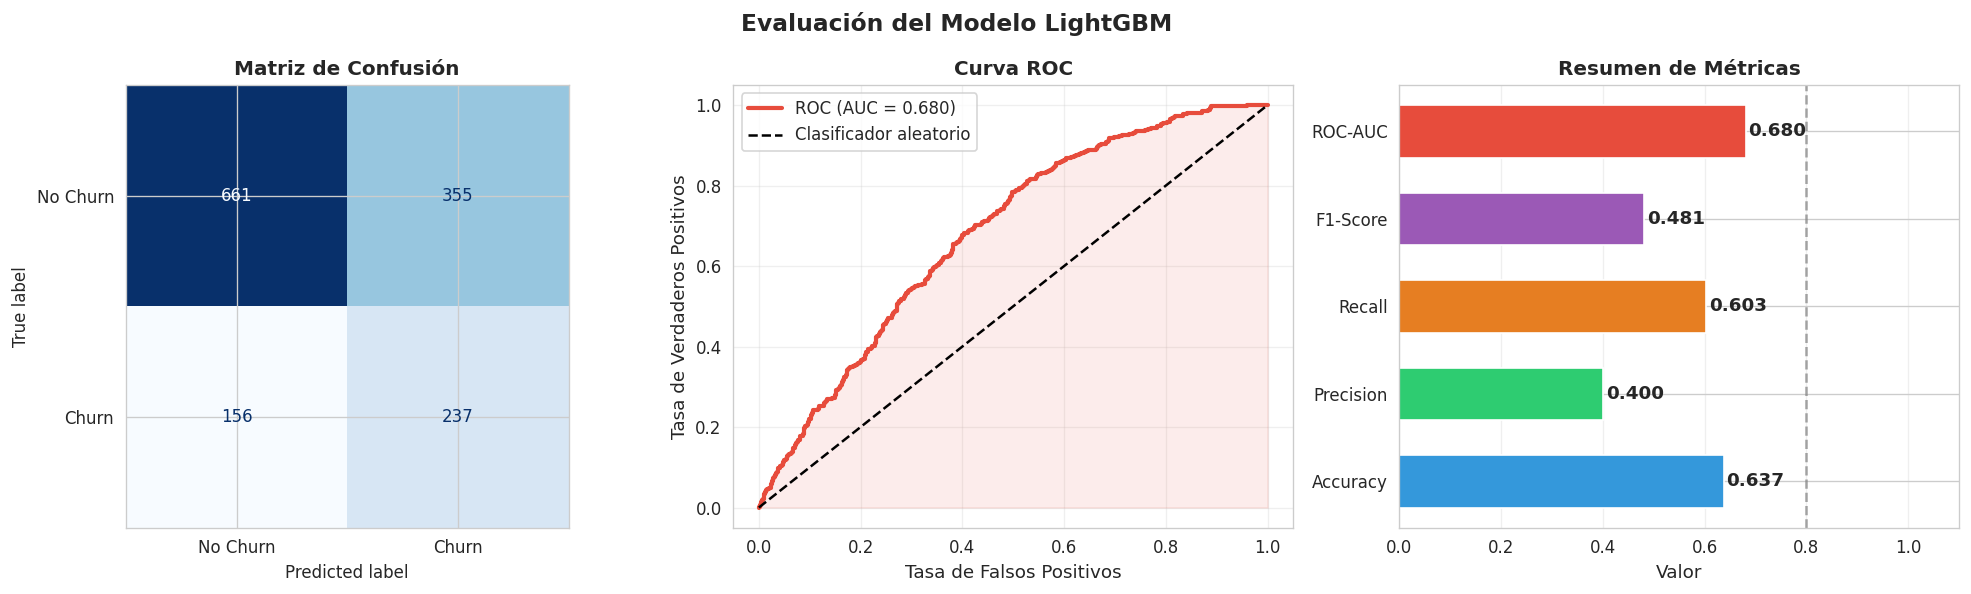

In [ ]:
# ─── Visualización de métricas ───
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Evaluación del Modelo LightGBM', fontsize=14, fontweight='bold')

# ── 1. Matriz de Confusión ──
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')

# ── 2. Curva ROC ──
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# ── 3. Métricas en barra ──
metricas = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc}
colors_met = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']
bars = axes[2].barh(list(metricas.keys()), list(metricas.values()),
                    color=colors_met, edgecolor='white', height=0.6)
for bar, val in zip(bars, metricas.values()):
    axes[2].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
axes[2].set_xlim(0, 1.1)
axes[2].set_xlabel('Valor', fontsize=11)
axes[2].set_title('Resumen de Métricas', fontsize=12, fontweight='bold')
axes[2].axvline(0.8, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('evaluacion_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ajuste de Hiperparámetros

In [ ]:
# ─── Ajuste de Hiperparámetros (Grid Search simplificado) ───
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.07],
    'max_depth': [5, 6]
}

lgbm_gs = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    lgbm_gs, param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1 (CV):      {grid_search.best_score_:.4f}")

Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Mejor F1 (CV):      0.4868


In [ ]:
# ─── Evaluar modelo optimizado ───
best_model = grid_search.best_estimator_

y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_proba_opt)

print(f"\n{'='*55}")
print(f"  COMPARACIÓN: Modelo Base vs Optimizado")
print(f"{'='*55}")
print(f"  {'Métrica':<15} {'Base':>12} {'Optimizado':>12} {'Mejora':>10}")
print(f"  {'-'*50}")
for nombre, base_val, opt_val in [
    ('Accuracy', acc, acc_opt),
    ('Precision', prec, prec_opt),
    ('Recall', rec, rec_opt),
    ('F1-Score', f1, f1_opt),
    ('ROC-AUC', auc, auc_opt)
]:
    delta = opt_val - base_val
    signo = '+' if delta >= 0 else ''
    print(f"  {nombre:<15} {base_val:>12.4f} {opt_val:>12.4f} {signo}{delta:>9.4f}")


  COMPARACIÓN: Modelo Base vs Optimizado
  Métrica                 Base   Optimizado     Mejora
  --------------------------------------------------
  Accuracy              0.6373       0.6359   -0.0014
  Precision             0.4003       0.4077 +   0.0074
  Recall                0.6031       0.6743 +   0.0712
  F1-Score              0.4812       0.5081 +   0.0269
  ROC-AUC               0.6805       0.6909 +   0.0104


## 8. Interpretación de Resultados

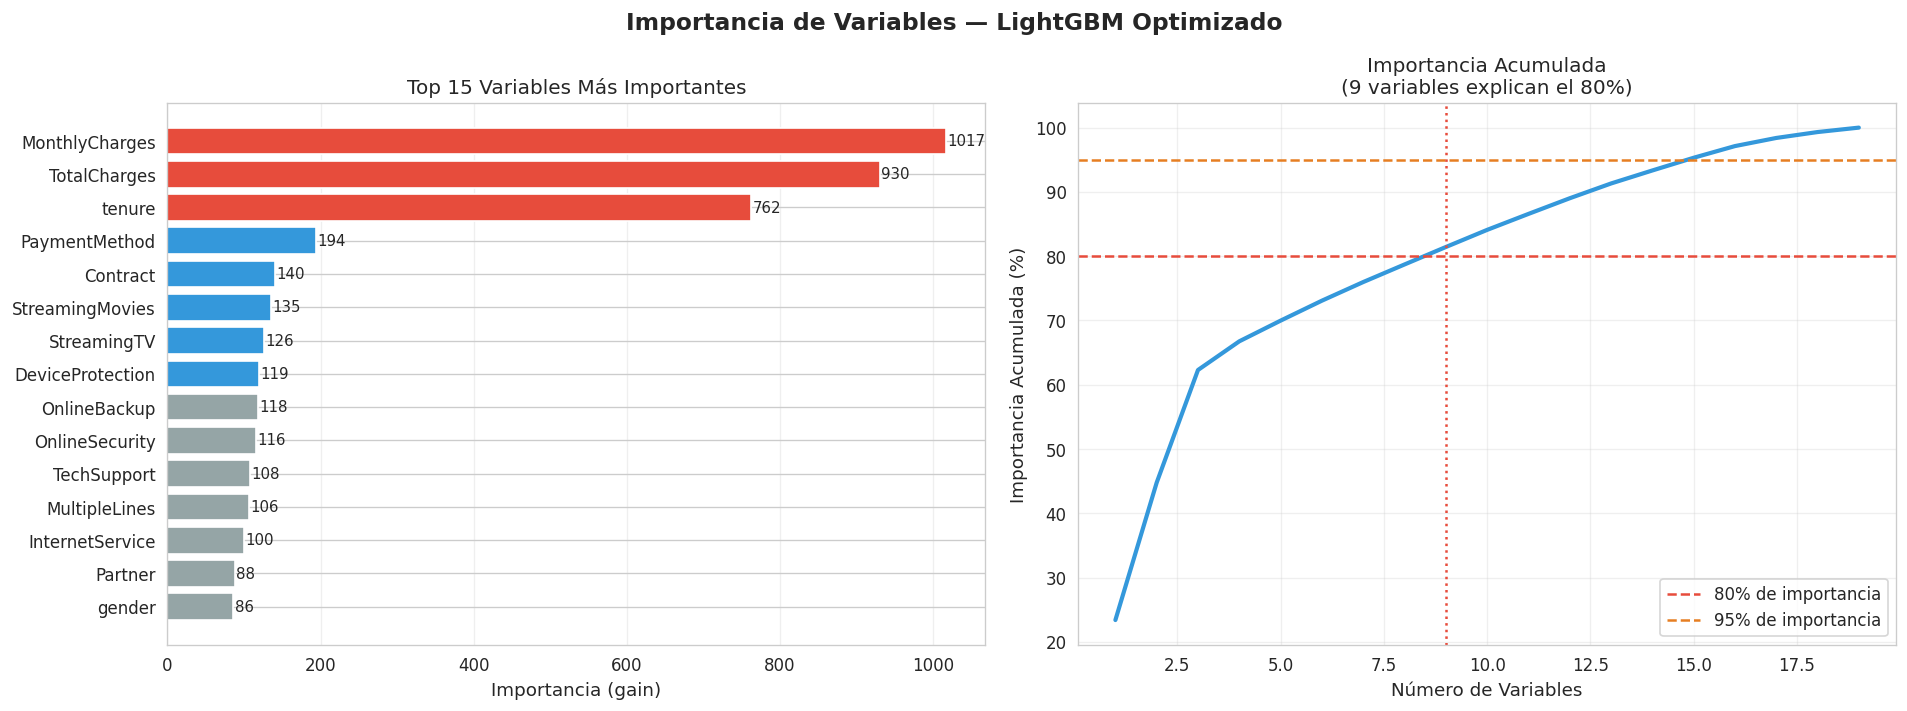


Top 5 variables más importantes:
  1. MonthlyCharges: 1017
  2. TotalCharges: 930
  3. tenure: 762
  4. PaymentMethod: 194
  5. Contract: 140


In [ ]:
# ─── Feature Importance ───
importances = pd.Series(
    best_model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importancia de Variables — LightGBM Optimizado', fontsize=14, fontweight='bold')

# Top 15 features
top15 = importances.head(15)
colors_fi = ['#e74c3c' if i < 3 else '#3498db' if i < 8 else '#95a5a6'
             for i in range(len(top15))]
bars = axes[0].barh(top15.index[::-1], top15.values[::-1],
                    color=colors_fi[::-1], edgecolor='white')
for bar, val in zip(bars, top15.values[::-1]):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=9)
axes[0].set_title('Top 15 Variables Más Importantes', fontsize=12)
axes[0].set_xlabel('Importancia (gain)', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

# Importancia acumulada
importancia_acumulada = importances.cumsum() / importances.sum() * 100
axes[1].plot(range(1, len(importancia_acumulada)+1), importancia_acumulada.values,
             color='#3498db', linewidth=2.5)
axes[1].axhline(80, color='#e74c3c', linestyle='--', linewidth=1.5,
                label='80% de importancia')
axes[1].axhline(95, color='#e67e22', linestyle='--', linewidth=1.5,
                label='95% de importancia')
n_80 = (importancia_acumulada <= 80).sum() + 1
axes[1].axvline(n_80, color='#e74c3c', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Número de Variables', fontsize=11)
axes[1].set_ylabel('Importancia Acumulada (%)', fontsize=11)
axes[1].set_title(f'Importancia Acumulada\n({n_80} variables explican el 80%)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 variables más importantes:")
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.0f}")

In [ ]:
# ─── Análisis de errores ───
df_errores = X_test.copy()
df_errores['y_real'] = y_test.values
df_errores['y_pred'] = y_pred_opt
df_errores['proba_churn'] = y_proba_opt
df_errores['error_tipo'] = 'Correcto'
df_errores.loc[(df_errores['y_real'] == 1) & (df_errores['y_pred'] == 0), 'error_tipo'] = 'Falso Negativo'
df_errores.loc[(df_errores['y_real'] == 0) & (df_errores['y_pred'] == 1), 'error_tipo'] = 'Falso Positivo'

conteo_errores = df_errores['error_tipo'].value_counts()
print(f"Análisis de errores:")
print(f"  Predicciones correctas: {conteo_errores.get('Correcto', 0):,}")
print(f"  Falsos Positivos:       {conteo_errores.get('Falso Positivo', 0):,} (cliente que NO se va, predicho como que SÍ)")
print(f"  Falsos Negativos:       {conteo_errores.get('Falso Negativo', 0):,} (cliente que SÍ se va, predicho como que NO)")
print(f"\n  ⚠️  Los Falsos Negativos son más costosos para el negocio")
print(f"     (perdemos clientes que podríamos haber retenido)")

Análisis de errores:
  Predicciones correctas: 896
  Falsos Positivos:       385 (cliente que NO se va, predicho como que SÍ)
  Falsos Negativos:       128 (cliente que SÍ se va, predicho como que NO)

  ⚠️  Los Falsos Negativos son más costosos para el negocio
     (perdemos clientes que podríamos haber retenido)


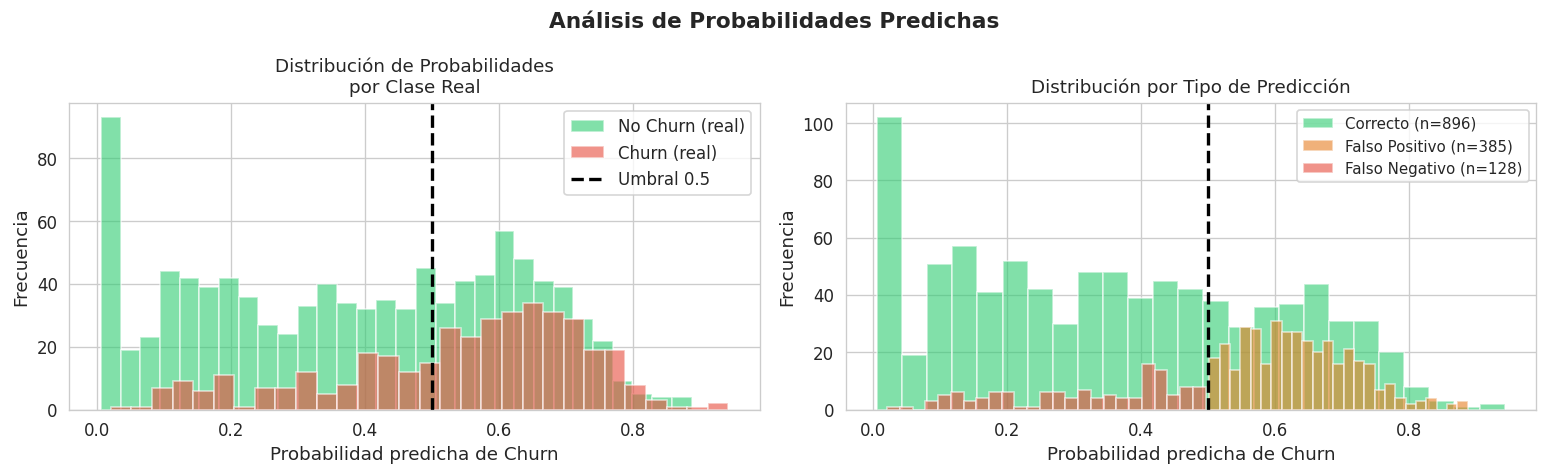

In [ ]:
# ─── Distribución de probabilidades predichas ───
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Análisis de Probabilidades Predichas', fontsize=13, fontweight='bold')

# Distribución por clase real
for clase, color, label in zip([0, 1], PALETTE, ['No Churn (real)', 'Churn (real)']):
    proba_clase = y_proba_opt[y_test.values == clase]
    axes[0].hist(proba_clase, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Umbral 0.5')
axes[0].set_xlabel('Probabilidad predicha de Churn', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Probabilidades\npor Clase Real', fontsize=11)
axes[0].legend(fontsize=10)

# Por tipo de error
tipos_colores = {'Correcto': '#2ecc71', 'Falso Positivo': '#e67e22', 'Falso Negativo': '#e74c3c'}
for tipo, color in tipos_colores.items():
    mask = df_errores['error_tipo'] == tipo
    if mask.sum() > 0:
        axes[1].hist(df_errores.loc[mask, 'proba_churn'], bins=25,
                     alpha=0.6, color=color, label=f'{tipo} (n={mask.sum()})', edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Probabilidad predicha de Churn', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución por Tipo de Predicción', fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 9. Conclusiones

In [ ]:
print(f"""
{'='*60}
  CONCLUSIONES — LightGBM para Predicción de Churn
{'='*60}

  RENDIMIENTO DEL MODELO:
  • El modelo optimizado alcanzó un F1-Score de {f1_opt:.3f} y
    ROC-AUC de {auc_opt:.3f}, indicando buen desempeño.
  • El Recall de {rec_opt:.3f} significa que detectamos el
    {rec_opt*100:.1f}% de los clientes que realmente hacen churn.

  VARIABLES MÁS IMPORTANTES:
  • {importances.index[0]} es el predictor más fuerte.
  • {importances.index[1]} y {importances.index[2]} también son
    altamente relevantes.
  • Solo {n_80} variables explican el 80% de la capacidad predictiva.

  LIMITACIONES:
  • El dataset tiene desbalance de clases (~26% churn) que
    puede afectar las métricas en producción.
  • El modelo no captura patrones temporales (series de tiempo).

  POSIBLES MEJORAS:
  • Usar SHAP values para explicabilidad más profunda.
  • Aplicar técnicas de oversampling (SMOTE) para el desbalance.
  • Incorporar variables de comportamiento temporal.
  • Optimizar el umbral de decisión según el costo del negocio.
""")


  CONCLUSIONES — LightGBM para Predicción de Churn

  RENDIMIENTO DEL MODELO:
  • El modelo optimizado alcanzó un F1-Score de 0.508 y
    ROC-AUC de 0.691, indicando buen desempeño.
  • El Recall de 0.674 significa que detectamos el
    67.4% de los clientes que realmente hacen churn.

  VARIABLES MÁS IMPORTANTES:
  • MonthlyCharges es el predictor más fuerte.
  • TotalCharges y tenure también son
    altamente relevantes.
  • Solo 9 variables explican el 80% de la capacidad predictiva.

  LIMITACIONES:
  • El dataset tiene desbalance de clases (~26% churn) que
    puede afectar las métricas en producción.
  • El modelo no captura patrones temporales (series de tiempo).

  POSIBLES MEJORAS:
  • Usar SHAP values para explicabilidad más profunda.
  • Aplicar técnicas de oversampling (SMOTE) para el desbalance.
  • Incorporar variables de comportamiento temporal.
  • Optimizar el umbral de decisión según el costo del negocio.

